# Wind Profile Over Gaussian Hill
This notebook cell reads `Hill.slicesWOT.plt`, selects one Tecplot zone, and plots vertical wind profiles together with a Gaussian hill reference.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.tri import Triangulation

In [26]:
# --- 1. Load and Clean Data ---
with open("Hill.slicesWOT.plt") as f:
    lines = f.read().splitlines()

raw_data = []
for line in lines:
    # Skip headers/zones and clean Fortran 'D' scientific notation
    if any(c in line for c in ['TITLE', 'VARIABLES', 'ZONE']):
        continue
    clean_line = line.replace('D', 'E').strip()
    if clean_line:
        raw_data.append([float(x) for x in clean_line.split()])

data = np.array(raw_data)

# Extract columns based on your VARIABLES="x","y","u","v","w","vort"
x = data[:, 0]
y = data[:, 1]
u = data[:, 2] # Streamwise velocity (matches your image label)
v = data[:, 3]
w = data[:, 4] # Vertical velocity
vort = data[:, 5]

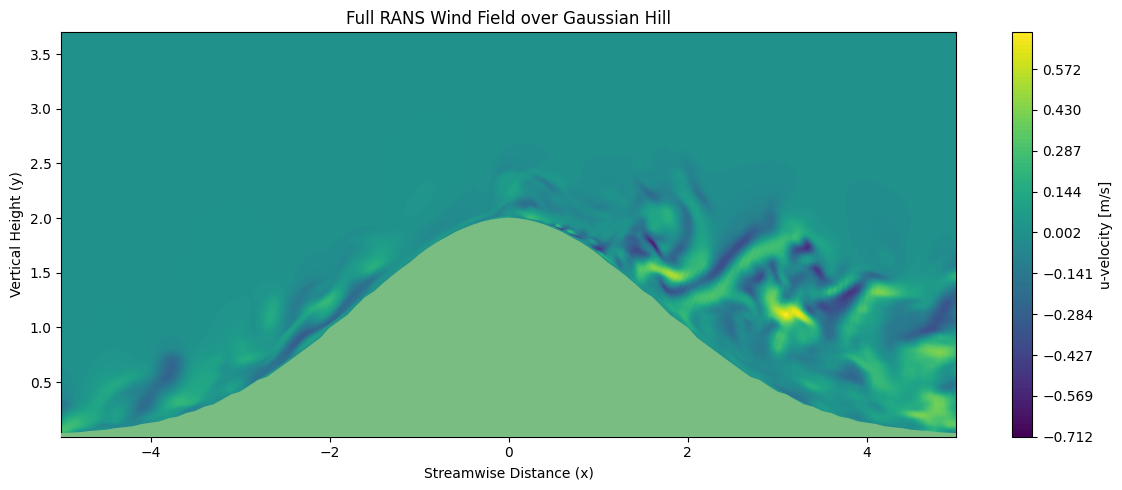

In [33]:
# --- 2. Plotting ---
plt.figure(figsize=(12, 5))

# Use tricontourf which handles non-rectangular grids (common in RANS)
# We plot 'u' velocity to match your provided image's colorbar label
levels = np.linspace(u.min(), u.max(), 100)
contour = plt.tricontourf(x, y, u, levels=levels, cmap='viridis') 

# Add the Colorbar
cbar = plt.colorbar(contour)
cbar.set_label('u-velocity [m/s]')

# Build a lower-envelope profile of the terrain and fill below it in green
x_round = x.round(decimals=1)
ground = np.array([[xv, y[x_round == xv].min()] for xv in np.unique(x_round) if -10 <= xv <= 10])
plt.fill_between(ground[:, 0], ground[:, 1], np.zeros_like(ground[:, 1]), color='#79bd82', zorder=3)


# --- 3. Styling the Hill ---
# To get the "Green Hill" look, we fill the area under the lowest points
# or simply set the background color of the plot.
plt.gca().set_facecolor("#74b77d") # Green color for the hill/ground

# Adjust limits to match your image focus
plt.xlim([-5, 5])
plt.ylim([y.min(), 3.7])

plt.xlabel('Streamwise Distance (x)')
plt.ylabel('Vertical Height (y)')
plt.title('Full RANS Wind Field over Gaussian Hill')

plt.tight_layout()
plt.show()

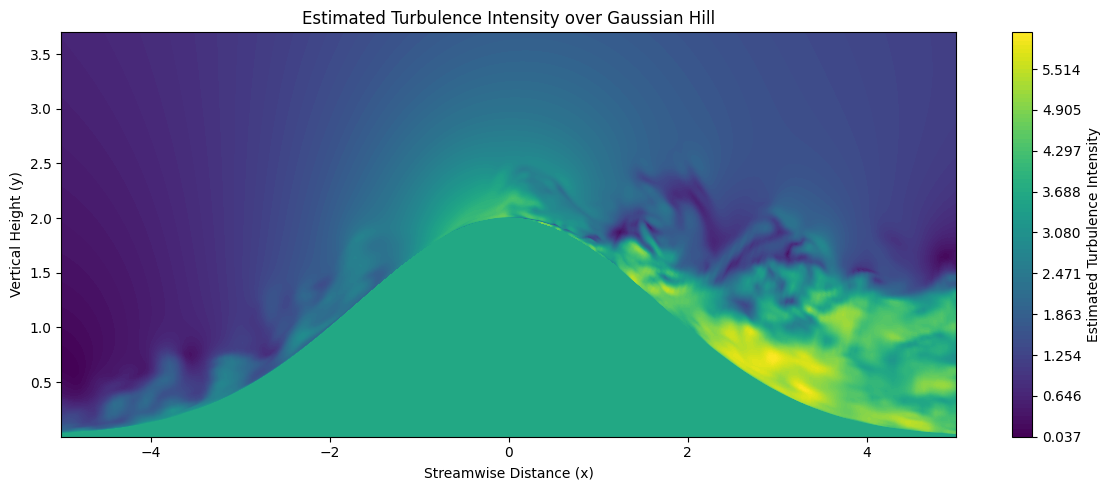

In [ ]:
# --- Compute reference velocity (free-stream estimate) ---
U_ref = np.percentile(u, 95)  # good estimate of incoming wind speed

# --- Fluctuation-like velocity magnitude ---
u_fluc = u - np.mean(u)
v_fluc = v - np.mean(v)
w_fluc = w - np.mean(w)

TI = np.sqrt((1/3)*(u_fluc**2 + v_fluc**2 + w_fluc**2)) / (U_ref)



# --- Plot Turbulence Intensity ---
plt.figure(figsize=(12, 5))

levels = np.linspace(TI.min(), TI.max(), 100)
contour = plt.tricontourf(x, y, TI, levels=levels, cmap='viridis')

cbar = plt.colorbar(contour)
cbar.set_label('Estimated Turbulence Intensity')

plt.gca().set_facecolor("#74b77d")

plt.xlim([-5, 5])
plt.ylim([y.min(), 3.7])

plt.xlabel('Streamwise Distance (x)')
plt.ylabel('Vertical Height (y)')
plt.title('Estimated Turbulence Intensity over Gaussian Hill')

plt.tight_layout()
plt.show()